# SDG Project - Analisi Esplorativa del Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento dei dataset
# Nota: dataset.csv utilizza ';' come separatore e ',' come separatore decimale per i valori numerici
df = pd.read_csv('data/dataset.csv', sep=';', decimal=',')
data_desc = pd.read_csv('data/data_descriptions.csv', sep=';')

print("Dataset caricati con successo!")

Dataset caricati con successo!


### 1. Descrizione dataset 
Verifichiamo la dimensione complessiva del dataset (numero di righe e colonne), poi num colonne numeriche e categoriche

In [ ]:
from IPython.display import display
# 1. Shape del dataset (righe, colonne)
print(f"Shape del dataset: {df.shape[0]} righe, {df.shape[1]} colonne\n")

# Prime 5 righe
print("--- Prime 5 righe del dataset ---")
display(df.head())

# Tipi di dato delle colonne (dtypes)
# print("\n--- Tipi di dato (dtypes) - Prime 20 colonne ---")
# display(df.dtypes.to_frame(name='dtype').head(20))

# Elenco variabili con prefisso text_format nelle descrizioni
tf_vars = set(data_desc[data_desc['Variable'].astype(str).str.startswith('text_format')]['Variable'].astype(str).str.replace('text_format', '').str.lower())

# Classificazione colonne categoriche vs numeriche
cat_cols = [c for c in df.columns if str(df[c].dtype) in ['object', 'string', 'str'] or c.lower() in tf_vars]
num_cols = [c for c in df.columns if c not in cat_cols]

print(f"Numero Colonne Categoriche: {len(cat_cols)}")
# print(f"Colonne Categoriche: {cat_cols}\n")
print(f"Numero Colonne Numeriche: {len(num_cols)}\n")

# print("--- Describe Colonne Numeriche (Prime 10) ---")
# display(df[num_cols].describe().T.head(10))

# print("\n--- Describe Colonne Categoriche ---")
# display(df[cat_cols].describe().T)

# Numero di categorie uniche per ogni colonna categorica
cat_summary = pd.DataFrame({
    'colonna': cat_cols,
    'n_categorie': [df[c].nunique(dropna=True) for c in cat_cols],
    'n_missing': [df[c].isna().sum() for c in cat_cols]
}).sort_values('n_categorie', ascending=False).reset_index(drop=True)

# print(f"--- Numero di categorie per ciascuna delle {len(cat_cols)} colonne categoriche ---")
# display(cat_summary)


### 2. Distribuzione della Colonna Target "churn"
Analizziamo la distribuzione della variabile target `churn` sia in termini di frequenza assoluta che percentuale, per verificare il bilanciamento delle classi (presenza di eventuale class imbalance).
Classe 1 clienti abbandonano il servizio, classe 0 no.

In [ ]:
# Conteggio assoluto e percentuale della variabile target churn
churn_counts = df['churn'].value_counts(dropna=False)
churn_pct = df['churn'].value_counts(normalize=True, dropna=False) * 100

churn_dist = pd.DataFrame({
    'Conteggio Assoluto': churn_counts,
    'Percentuale (%)': churn_pct.round(2)
})

display(churn_dist)

# Valutazione del bilanciamento
pct_0, pct_1 = churn_pct.get(0, 0), churn_pct.get(1, 0)
print(f"\nDistribuzione target: Classe 0 = {pct_0:.2f}%, Classe 1 = {pct_1:.2f}%")
if abs(pct_0 - pct_1) < 10:
    print("Esito: La variabile target 'churn' risulta perfettamente bilanciata (~50% vs ~50%).")
else:
    print("Esito: La variabile target 'churn' risulta sbilanciata.")

### 3. Splitto il dataset in train, val e test
Lo suddivido in modo randomico 70% construction e 30% test, poi il construction in train e val (85, 15)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Creo una copia di df da usare per lo split
df_clean = df.copy()

# # Controllo il formato delle colonne 
# print(df_clean.dtypes)

#Imposto Customer_ID come colonna indice 
df_clean = df_clean.set_index('Customer_ID')

# Split in train e test set
X = df_clean.drop(columns=['churn'])  
y = df_clean['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)

# Numero di righe in train e test set
print(f"Dimensione training set: {X_train_model.shape[0]} righe")
print(f"Dimensione validation set: {X_val.shape[0]} righe")
print(f"Dimensione test set: {X_test.shape[0]} righe")

Dimensione training set: 59500 righe
Dimensione validation set: 10500 righe
Dimensione test set: 30000 righe


In [ ]:
# Numero di righe in train e test set
total = len(X_train_model) + len(X_val) + len(X_test)

print(f"Training set:   {len(X_train_model):>7,} rows ({len(X_train_model)/total:.1%})")
print(f"Validation set: {len(X_val):>7,} rows ({len(X_val)/total:.1%})")
print(f"Test set:       {len(X_test):>7,} rows ({len(X_test)/total:.1%})")

### 4. Analisi dei Missing Values (MVs)
Calcoliamo il numero di missing values (`null/NaN`) per ciascuna colonna.
L'output è ordinato in modo decrescente e include esclusivamente le colonne con un numero di valori mancanti superiore a zero (`missing > 0`).

Impostiamo una soglia del 30% e attuiamo la strategia di gestione dei MVs:

**Numeriche**
MVs > 30%: Rimozione colonna
MVs < 30%: Imputazione con mediana

**Categoriche**
Categoria ‘MISSING’


In [ ]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class MissingValueHandler(BaseEstimator, TransformerMixin):
    """
    Gestisce i missing values secondo la strategia:
    - Colonne numeriche/categoriche con MVs > soglia: rimosse
    - Colonne numeriche con MVs <= soglia: imputate con la mediana (calcolata sul train)
    - Colonne categoriche con MVs <= soglia: imputate con 'MISSING'
    """
    def __init__(self, threshold=30, impute_numeric_values: bool = False):
        self.threshold = threshold
        self.impute_numeric_values = impute_numeric_values

    def fit(self, X, y=None):
        X = X.copy()
        missing_pct = (X.isnull().sum() / len(X)) * 100
        num_cols = X.select_dtypes(include=[np.number]).columns
        cat_cols = X.select_dtypes(include=['object', 'string']).columns

        num_gt30 = missing_pct[(missing_pct.index.isin(num_cols)) & (missing_pct > self.threshold)]
        cat_gt30 = missing_pct[(missing_pct.index.isin(cat_cols)) & (missing_pct > self.threshold)]

        self.cols_to_drop_ = num_gt30.index.tolist() + cat_gt30.index.tolist()

        remaining_num_cols = [c for c in num_cols if c not in self.cols_to_drop_]
        if self.impute_numeric_values:
            self.medians_ = {col: X[col].median() for col in remaining_num_cols}
        else:
            self.medians_ = {}
            
        self.remaining_cat_cols_ = [c for c in cat_cols if c not in self.cols_to_drop_]

        return self

    def transform(self, X):
        X = X.copy()
        X = X.drop(columns=[c for c in self.cols_to_drop_ if c in X.columns])
        for col, median_value in self.medians_.items():
            if col in X.columns:
                X[col] = X[col].fillna(median_value)
        for col in self.remaining_cat_cols_:
            if col in X.columns:
                X[col] = X[col].fillna('MISSING')
        return X

    def summary(self):
        """Returns a summary dictionary and prints stats in English."""
        summary_data = {
            'Dropped Numeric Columns': len(self.dropped_num_cols_),
            'Dropped Categorical Columns': len(self.dropped_cat_cols_),
            'Imputed Numeric Columns': len(self.imputed_num_cols_),
            'Imputed Categorical Columns': len(self.imputed_cat_cols_),
        }

        print("=== MISSING VALUE HANDLING SUMMARY ===")
        for key, val in summary_data.items():
            print(f"{key}: {val}")
        print("=====================================")

        return summary_data

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder

# Usiamo make_column_selector per selezionare le colonne categoriche dinamicamente
# DOPO l'esecuzione di MissingValueHandler nella Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            make_column_selector(dtype_include=['object', 'string']),
        )
    ],
    remainder='passthrough',  # le numeriche passano invariate
)


Analisi su quali colonne vengono rimosse / imputate

In [14]:
# Soglia utilizzata nel MissingValueHandler
threshold = 30

# Percentuale di missing per ogni colonna
missing_pct = (df.isnull().sum() / len(df)) * 100

# Identifico colonne numeriche e categoriche
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns

# Colonne eliminate dalla logica del MissingValueHandler
dropped_num_cols = missing_pct[
    missing_pct.index.isin(num_cols) & (missing_pct > threshold)
].index.tolist()

dropped_cat_cols = missing_pct[
    missing_pct.index.isin(cat_cols) & (missing_pct > threshold)
].index.tolist()

dropped_cols = dropped_num_cols + dropped_cat_cols

print(f"Numero colonne eliminate: {len(dropped_cols)}")
print(f"  - Numeriche: {len(dropped_num_cols)}")
print(f"  - Categoriche: {len(dropped_cat_cols)}")

print("\nColonne eliminate:")
for col in dropped_cols:
    print(f"- {col}")

Numero colonne eliminate: 6
  - Numeriche: 2
  - Categoriche: 4

Colonne eliminate:
- lor
- numbcars
- ownrent
- dwlltype
- HHstatin
- dwllsize


## GRADIENT BOOSTING- esploriamo le features

In [ ]:
### 8. Confronto con Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV


gb_pipeline = Pipeline([
    ('missing_handler', MissingValueHandler(threshold=30)),
    ('preprocessor', preprocessor),
    ('gb', GradientBoostingClassifier(random_state=42))
])

# # --- Stratified K-Fold (k=5) ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gb_param_grid = {
    'gb__n_estimators': [100, 200],
    'gb__max_depth': [3, 5],
    'gb__learning_rate': [0.05, 0.1]
}

gb_grid_search = GridSearchCV(
    gb_pipeline,
    param_grid=gb_param_grid,
    cv=skf,              #  StratifiedKFold 
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

gb_grid_search.fit(X_train_model, y_train_model)  

print("Migliori iperparametri GBM:")
print(gb_grid_search.best_params_)
print(f"Miglior roc_auc medio in CV: {gb_grid_search.best_score_:.4f}")

In [ ]:
threshold = 30
total_rows = len(X_train_model)

# 1. Percentuale missing per colonna
missing_pct = (X_train_model.isnull().sum() / total_rows) * 100

# 2. Identificazione colonne
num_cols = X_train_model.select_dtypes(include=[np.number]).columns
cat_cols = X_train_model.select_dtypes(include=['object', 'string']).columns

# 3. Colonne rimosse (> threshold)
dropped_num = missing_pct[
    (missing_pct.index.isin(num_cols)) & (missing_pct > threshold)
].index.tolist()
dropped_cat = missing_pct[
    (missing_pct.index.isin(cat_cols)) & (missing_pct > threshold)
].index.tolist()

all_dropped = dropped_num + dropped_cat

# 4. Colonne rimaste che avevano valori mancanti (imputate)
remaining_num = [c for c in num_cols if c not in all_dropped]
remaining_cat = [c for c in cat_cols if c not in all_dropped]

imputed_num = [c for c in remaining_num if X_train_model[c].isnull().any()]
imputed_cat = [c for c in remaining_cat if X_train_model[c].isnull().any()]

# === PRINT SUMMARY ===
print("=== MISSING VALUE HANDLING SUMMARY ===")
print(f"Dropped Numeric Columns: {len(dropped_num)}")
print(f"Dropped Categorical Columns: {len(dropped_cat)}")
print(f"Imputed Numeric Columns: {len(imputed_num)}")
print(f"Imputed Categorical Columns: {len(imputed_cat)}")
print("=====================================")

In [ ]:
print("Gradient Boosting Model")
print("Best hyper parameters:", gb_grid_search.best_params_)
print(f"Best ROC-AUC in CV: {gb_grid_search.best_score_:.4f}")
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

gb_best_model = gb_grid_search.best_estimator_

# Probabilità sul validation set
y_proba_val_gb = gb_best_model.predict_proba(X_val)[:, 1]
print(f"Best ROC-AUC in Validation Set: {roc_auc_score(y_val, y_proba_val_gb):.4f}" )

In [ ]:
### 9. Predizioni sul validation set per la scelta della soglia

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

gb_best_model = gb_grid_search.best_estimator_

# Probabilità sul validation set
y_proba_val_gb = gb_best_model.predict_proba(X_val)[:, 1]

print(f"ROC-AUC in Validation Set GBM: {roc_auc_score(y_val, y_proba_val_gb):.4f}")

Lavoro sulle soglie di classificazione per aumentare le performance ottimizzando RECALL a discapito della precision -> preferisco falsi positivi che falsi negativi (?) 
Scelta da discutere

n.b 
precision = tp/(tp+fp)

recall=tp/(tp+fn)

In [ ]:
### 10. Analisi soglie di decisione sul Gradient Boosting

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.95, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_proba_val_gb >= t).astype(int)

    precision = precision_score(y_val, y_pred_t, zero_division=0)
    recall = recall_score(y_val, y_pred_t, zero_division=0)
    f1 = f1_score(y_val, y_pred_t, zero_division=0)

    results.append({
        'threshold': round(t, 2),
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

threshold_df_gb = pd.DataFrame(results)

display(threshold_df_gb)

# Soglia che massimizza F1 sul validation set
best_row = threshold_df_gb.loc[threshold_df_gb['f1'].idxmax()]

best_threshold_gb = best_row['threshold']

print(
    f"\nOptimal F1 threshold (validation): "
    f"{best_threshold_gb:.2f} (F1 = {best_row['f1']:.4f})"
)

In [ ]:
### 11. Permutation Importance sul Gradient Boosting

from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np

perm_result_gb = permutation_importance(
    gb_best_model,
    X_val,
    y_val,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='roc_auc'
)

# Nomi delle feature originali
feature_names_gb = X_val.columns

importance_df_gb = pd.DataFrame({
    'Feature': feature_names_gb,
    'Importance_Mean': perm_result_gb.importances_mean,
    'Importance_Std': perm_result_gb.importances_std
}).sort_values(
    by='Importance_Mean',
    ascending=False
).reset_index(drop=True)

print("--- Best 25 features  ---")
display(importance_df_gb.head(25))

N.B Permutation Importance- mi dice ad esempio quando la variabile viene permutata casualmente l'F1 del modello peggiora di 0.024 punti.

## Visualizzazione delle features pià significative

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

TOP_25_FEATURES = [
    "eqpdays", "months", "mou_Mean", "change_mou", "totmrc_Mean",
    "avgqty", "uniqsubs", "avgmou", "drop_vce_Mean", "hnd_price",
    "mou_cvce_Mean", "change_rev", "avgrev", "ethnic", "avg3mou",
    "rev_Mean", "ovrmou_Mean", "mou_peav_Mean", "totrev", "totcalls",
    "avg6mou", "crclscod", "ovrrev_Mean", "asl_flag", "opk_vce_Mean"
]

sns.set_theme(style="whitegrid")

top_n = 6
features_to_plot = TOP_25_FEATURES[:top_n]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

df_plot = X_val[features_to_plot].copy()
# Mappiamo subito 0 e 1 con le etichette di testo per evitare il UserWarning sui tick
df_plot['churn_label'] = y_val.map({0: 'No Churn (0)', 1: 'Churn (1)'}).values

for i, col in enumerate(features_to_plot):
    ax = axes[i]
    
    if df_plot[col].nunique() <= 10 or df_plot[col].dtype == 'object':
        # Per le categoriche calcoliamo la % direttamente su y_val
        churn_rate = X_val.assign(churn=y_val).groupby(col)['churn'].mean().reset_index()
        sns.barplot(data=churn_rate, x=col, y='churn', ax=ax, palette='Blues_d')
        ax.set_title(f'% Churn per {col}', fontsize=12, fontweight='bold')
        ax.set_ylabel('Tasso di Churn')
        ax.set_ylim(0, 1)
        
    else:
        # Usiamo x come hue ed evitiamo la legenda per risolvere il FutureWarning
# Nel ciclo for, sostituisci il boxplot con questo:
        sns.boxplot(
            data=df_plot, 
            x='churn_label', 
            y=col, 
            hue='churn_label',
            order=['No Churn (0)', 'Churn (1)'], # Forza l'ordine: No Churn prima, Churn dopo
            palette=['#2ecc71', '#e74c3c'],      # Verde per No Churn, Rosso per Churn
            ax=ax, 
            legend=False,
            showfliers=False 
        )
        ax.set_title(f'Distribuzione di {col} vs Churn', fontsize=12, fontweight='bold')
        ax.set_xlabel('')

plt.tight_layout()
plt.show()

## PROVA REGRESSIONE LOGISTICA BASE SOLO PER ISPEZIONE

In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

print("="*60)
print("--- TEST RAPIDO: REGRESSIONE LOGISTICA BASE (SOLO ISPEZIONE) ---")
print("="*60)

# ============================================================
# 1. RECUPERO DELLE TOP 25 FEATURE ED ESTRAZIONE SICURA
# ============================================================
# Se 'top_features' esiste usiamo quella, altrimenti la prendiamo da 'metadata'
if 'top_features' in locals():
    selected_cols = list(top_features)
elif 'metadata' in locals():
    selected_cols = metadata['features']
else:
    # Se per qualche motivo non sono in memoria, usiamo le prime 25 colonne di X_train
    selected_cols = X_train.columns[:25].tolist()

# Copia isolata dei dataset filtrati sulle 25 feature
X_tr_lr = X_train[selected_cols].copy()
X_te_lr = X_test[selected_cols].copy()
y_tr_lr = y_train.copy()
y_te_lr = y_test.copy()

# ============================================================
# 2. COSTRUZIONE PIPELINE LOGISTIC REGRESSION
# ============================================================
num_cols_lr = X_tr_lr.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_lr = X_tr_lr.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols_lr),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols_lr)
    ]
)

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

# ============================================================
# 3. FIT & VALUTAZIONE SUL TEST SET
# ============================================================
lr_pipeline.fit(X_tr_lr, y_tr_lr)

y_proba_lr_test = lr_pipeline.predict_proba(X_te_lr)[:, 1]
y_pred_lr_040 = (y_proba_lr_test >= 0.40).astype(int)

auc_lr = roc_auc_score(y_te_lr, y_proba_lr_test)

print(f"\n[LR] ROC-AUC Test Set: {auc_lr:.4f}")
print("\n--- Report Classificazione Logistic Regression (Threshold 0.40) ---")
print(classification_report(y_te_lr, y_pred_lr_040, digits=4))

print("Confusion Matrix (Threshold 0.40):")
print(confusion_matrix(y_te_lr, y_pred_lr_040))
print("="*60)

# ============================================================
# 4. ISPEZIONE DEI COEFFICIENTI (RELAZIONI LINEARI)
# ============================================================
raw_names_lr = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()
clean_names_lr = [
    f.replace('num__', '').replace('cat__', '') 
    for f in raw_names_lr
]

coefficients = lr_pipeline.named_steps['lr'].coef_[0]

df_coef = pd.DataFrame({
    'Feature': clean_names_lr,
    'Coefficient (Log-Odds)': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values(by='Abs_Coefficient', ascending=False)

print("\n--- Top 10 Feature per Impatto Lineare (Logistic Regression) ---")
display(df_coef[['Feature', 'Coefficient (Log-Odds)']].head(10))

## XG Boost su dataset ridotto a 25 top features

In [4]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, StratifiedKFold
TOP_25_FEATURES = [
    "eqpdays",
    "months",
    "mou_Mean",
    "change_mou",
    "totmrc_Mean",
    "avgqty",
    "uniqsubs",
    "avgmou",
    "drop_vce_Mean",
    "hnd_price",
    "mou_cvce_Mean",
    "change_rev",
    "avgrev",
    "ethnic",
    "avg3mou",
    "rev_Mean",
    "ovrmou_Mean",
    "mou_peav_Mean",
    "totrev",
    "totcalls",
    "avg6mou",
    "crclscod",
    "ovrrev_Mean",
    "asl_flag",
    "opk_vce_Mean",
]


# 1. Lista delle colonne categoriche testuali
cat_cols = ['ethnic', 'crclscod', 'asl_flag']

# 2. Convertiamo le colonne in tipo 'category' sia su Train che su Validation
X_train_xgb = X_train_model[TOP_25_FEATURES].copy()
X_val_xgb = X_val[TOP_25_FEATURES].copy()

for col in cat_cols:
    X_train_xgb[col] = X_train_xgb[col].astype('category')
    X_val_xgb[col] = X_val_xgb[col].astype('category')

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_base = XGBClassifier(
    random_state=42,
    enable_categorical=True,
    eval_metric='logloss'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_xgb, y_train_model)

print("Best hyperparameters:", grid_search.best_params_)
print("Best ROC-AUC in CV:", grid_search.best_score_)

best_xgb = grid_search.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.8s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.8s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.8s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.9s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=   1.0s
[CV] END 

In [12]:
print("XG Boost Model")
print("\nBest hyperparameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"Best ROC-AUC in CV:{grid_search.best_score_:.4f}")
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix



# 1. Predizioni sul validation set
y_pred_xgb = best_xgb.predict(X_val_xgb)
y_pred_proba_xgb = best_xgb.predict_proba(X_val_xgb)[:, 1]  # probabilità della classe 1 (churn)
# 3. ROC-AUC sul validation set (da confrontare con quello in CV)
val_roc_auc = roc_auc_score(y_val, y_pred_proba_xgb)
print(f"ROC-AUC in Validation Set: {val_roc_auc:.4f}")

XG Boost Model

Best hyperparameters:
  colsample_bytree: 0.8
  learning_rate: 0.05
  max_depth: 5
  n_estimators: 300
  subsample: 0.8
Best ROC-AUC in CV:0.6862
ROC-AUC in Validation Set: 0.6967


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt


print("Classification Report:")
print(classification_report(y_val, y_pred_xgb))

# 4. Confusion Matrix
cm = confusion_matrix(y_val, y_pred_xgb)
print("Confusion Matrix:")
print(cm)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Calcolo della matrice di confusione
cm = confusion_matrix(y_val, y_pred_xgb)

# 2. Creazione del grafico con Seaborn
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False,
    xticklabels=['No Churn (0)', 'Churn (1)'],
    yticklabels=['No Churn (0)', 'Churn (1)']
)

plt.title('Confusion Matrix - XGBoost', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predizione del Modello', fontsize=12)
plt.ylabel('Valore Reale', fontsize=12)
plt.show()

=== CLASSIFICATION REPORT (Soglia = 0.40) ===
              precision    recall  f1-score   support

           0       0.64      0.65      0.65      5296
           1       0.64      0.64      0.64      5204

    accuracy                           0.64     10500
   macro avg       0.64      0.64      0.64     10500
weighted avg       0.64      0.64      0.64     10500



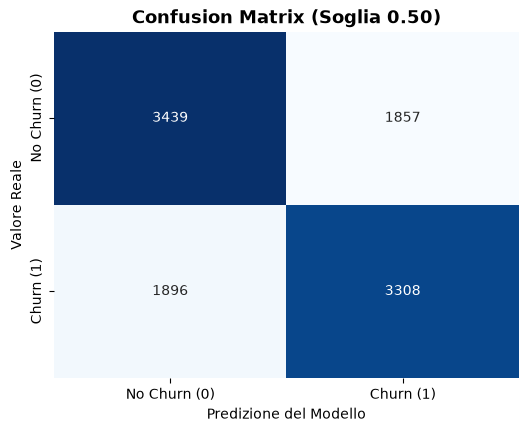

In [7]:
# customizzo la soglia
from sklearn.metrics import classification_report, confusion_matrix

# 1. Calcoliamo le probabilità anziché le predizioni dirette
y_probs = best_xgb.predict_proba(X_val_xgb)[:, 1]

# 2. Applichiamo la nuova soglia a 0.40
y_pred_04 = (y_probs >= 0.5).astype(int)

# 3. Report delle metriche
print("=== CLASSIFICATION REPORT (Soglia = 0.40) ===")
print(classification_report(y_val, y_pred_04))

# 4. Matrice di confusione comparativa
cm_04 = confusion_matrix(y_val, y_pred_04)

plt.figure(figsize=(6, 4.5))
sns.heatmap(
    cm_04, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False,
    xticklabels=['No Churn (0)', 'Churn (1)'],
    yticklabels=['No Churn (0)', 'Churn (1)']
)
plt.title('Confusion Matrix (Soglia 0.50)', fontsize=13, fontweight='bold')
plt.xlabel('Predizione del Modello')
plt.ylabel('Valore Reale')
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

# ROC-AUC (usa le probabilità continue, non y_pred!)
roc_auc = roc_auc_score(y_val, y_probs)
print(f"ROC-AUC: {roc_auc:.4f}")

# Opzionale: plot della curva ROC
fpr, tpr, thresholds = roc_curve(y_val, y_probs)

plt.figure(figsize=(6, 4.5))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.4f})', color='navy')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost', fontsize=13, fontweight='bold')
plt.legend()
plt.show()

=== FINAL RESULTS - TEST SET ===
              precision    recall  f1-score   support

           0     0.6375    0.6275    0.6324     15131
           1     0.6269    0.6369    0.6318     14869

    accuracy                         0.6321     30000
   macro avg     0.6322    0.6322    0.6321     30000
weighted avg     0.6322    0.6321    0.6321     30000


=== METRICHE DETTAGLIATE (Classe 1) ===
Accuracy : 0.6321
Precision: 0.6269
Recall   : 0.6369
F1-Score : 0.6318
ROC AUC  : 0.6894


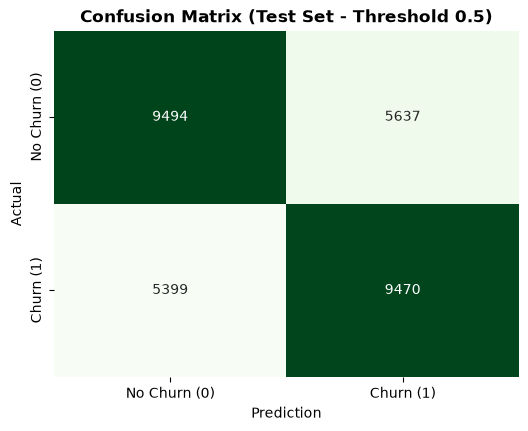

In [9]:
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    precision_score, 
    recall_score, 
    f1_score, 
    accuracy_score, 
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepariamo X_test applicando il tipo 'category' alle colonne testuali
X_test_xgb = X_test[TOP_25_FEATURES].copy()

for col in cat_cols:
    X_test_xgb[col] = X_test_xgb[col].astype('category')

# 2. Calcoliamo le probabilità sul TEST SET
y_test_probs = best_xgb.predict_proba(X_test_xgb)[:, 1]

# 3. Applichiamo la soglia scelta (es. 0.50)
chosen_threshold = 0.50
y_test_pred = (y_test_probs >= chosen_threshold).astype(int)

# 4. Stampa delle metriche finali (Report standard)
print("=== FINAL RESULTS - TEST SET ===")
print(classification_report(y_test, y_test_pred, digits=4))  # digits=4 evita l'arrotondamento visivo a 2 cifre

# 5. Stampa delle singole metriche ad alta precisione
print("\n=== METRICHE DETTAGLIATE (Classe 1) ===")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-Score : {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_test_probs):.4f}")  # Si calcola sulle probabilità, non sulle predizioni binari

# 6. Confusion Matrix Finale
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4.5))
sns.heatmap(
    cm_test, 
    annot=True, 
    fmt='d', 
    cmap='Greens', 
    cbar=False,
    xticklabels=['No Churn (0)', 'Churn (1)'],
    yticklabels=['No Churn (0)', 'Churn (1)']
)
plt.title(f'Confusion Matrix (Test Set - Threshold {chosen_threshold})', fontsize=12, fontweight='bold')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

# Visualizzazione della curva ROC + trade off + CM

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    roc_auc_score
)

# Configurazione stile grafico
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(20, 5))


# ============================================================
# 1. CURVA ROC
# ============================================================

fpr, tpr, _ = roc_curve(
    y_test,
    y_test_probs
)

auc_score_test = roc_auc_score(
    y_test,
    y_test_probs
)

axes[0].plot(
    fpr,
    tpr,
    color='darkorange',
    lw=2,
    label=f'ROC curve (AUC = {auc_score_test:.2f})'
)

axes[0].plot(
    [0, 1],
    [0, 1],
    color='navy',
    lw=1.5,
    linestyle='--'
)

axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC - XGBoost')
axes[0].legend(loc='lower right')


# ============================================================
# 2. CURVA PRECISION-RECALL
# ============================================================

precisions, recalls, thresholds = precision_recall_curve(
    y_test,
    y_test_probs
)

axes[1].plot(
    thresholds,
    precisions[:-1],
    'b--',
    label='Precision',
    lw=2
)

axes[1].plot(
    thresholds,
    recalls[:-1],
    'g-',
    label='Recall',
    lw=2
)

# Threshold finale scelta sul validation set
axes[1].axvline(
    x=0.50,
    color='red',
    linestyle=':',
    label='Threshold = 0.50'
)

axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Trade-off Precision vs Recall')
axes[1].legend(loc='center left')


# ============================================================
# 3. CONFUSION MATRIX - THRESHOLD 0.50
# ============================================================

cm_40 = confusion_matrix(
    y_test,
    y_test_pred
)

sns.heatmap(
    cm_40,
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[2],
    cbar=False,
    xticklabels=['No Churn (0)', 'Churn (1)'],
    yticklabels=['No Churn (0)', 'Churn (1)']
)

axes[2].set_xlabel('Predicted Class')
axes[2].set_ylabel('Actual Class')
axes[2].set_title('Confusion Matrix - Threshold 0.40')


plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve

# Configurazione stile e figura
sns.set_theme(style='whitegrid')
plt.figure(figsize=(8, 6))

# Calcolo Precision e Recall
precisions, recalls, thresholds = precision_recall_curve(
    y_test,
    y_test_probs
)

# Plot delle curve (usando plt al posto di axes[1])
plt.plot(
    thresholds,
    precisions[:-1],
    'b--',
    label='Precision',
    lw=2
)

plt.plot(
    thresholds,
    recalls[:-1],
    'g-',
    label='Recall',
    lw=2
)

# Soglia scelta
plt.axvline(
    x=0.50,
    color='red',
    linestyle=':',
    label='Threshold = 0.50'
)

# Etichette, titolo e legenda (usando le funzioni dirette di plt)
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Trade-off Precision vs Recall')
plt.legend(loc='center left')

plt.tight_layout()
plt.show()

# Analisi SHAP: verifico entità e direzione delle variabili

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# ============================================================
# 1. PREPARAZIONE DEL TEST SET (XGBoost Native Categorical)
# ============================================================

# Utilizziamo direttamente X_test_xgb già preparato con i tipi 'category'
# Se vuoi calcolare SHAP su tutto il test set o su un sample, mantieni le colonne TOP 25
X_test_shap = X_test_xgb.copy()


# ============================================================
# 2. CALCOLO SHAP VALUES PER XGBOOST
# ============================================================

# Inizializziamo il TreeExplainer direttamente sul miglior modello XGBoost
explainer = shap.TreeExplainer(best_xgb)

# Campionamento di 1000 righe casuali per velocizzare il calcolo (opzionale)
rng = np.random.RandomState(42)
sample_size = min(1000, X_test_shap.shape[0])
sample_indices = rng.choice(X_test_shap.shape[0], size=sample_size, replace=False)

shap_sample_df = X_test_shap.iloc[sample_indices]

# Calcolo degli SHAP values
# NOTA: Per classificazione binaria in XGBoost, shap_values conterrà le attibuzioni per la classe positiva
shap_values = explainer(shap_sample_df)


# ============================================================
# 3. SHAP SUMMARY PLOT (BEESWARM - TOP 10)
# ============================================================

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, 
    shap_sample_df, 
    max_display=5, 
    show=False
)
plt.title("SHAP Summary Plot - Top 5 Features ", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


# ============================================================
# 4. SHAP BAR PLOT (TOP 10 SENZA RIGA "SUM OF OTHERS")
# ============================================================

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, 
    shap_sample_df, 
    plot_type='bar', 
    max_display=5, 
    show=False
)
plt.title("SHAP Feature Importance - Top 5 Features", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Descrizione features piu rilevanti
feature_labels = {

    'eqpdays': 'Number of days (age) of current mobile phone',

    'months': 'Total number of months in service',

    'mou_Mean': 'Mean number of monthly minutes of use',

    'change_mou': 'Percentage change in monthly minutes of use vs previous three month average',

    'hnd_price': 'Current handset price',

    'drop_vce_Mean': 'Mean number of dropped (failed) voice calls',

    'crclscod': 'Credit class code',

    'avgmou': 'Average monthly minutes of use over the life of the customer',

    'totmrc_Mean': 'Mean total monthly recurring charge',

    'uniqsubs': 'Number of unique subscribers in the household'
    
}

